In [ ]:
!pip install transformers datasets torchaudio librosa scikit-learn -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random

from datasets import load_dataset, concatenate_datasets, Audio
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm import tqdm

In [ ]:
dataset = load_dataset("stapesai/ssi-speech-emotion-recognition")

full_dataset = concatenate_datasets([
    dataset["train"],
    dataset["validation"],
    dataset["test"]
])

print("Total samples:", len(full_dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/373M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/374M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/374M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1999 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/163 [00:00<?, ? examples/s]

Total samples: 12162


In [ ]:
emotions = sorted(list(set(full_dataset["emotion"])))

emotion2id = {e:i for i,e in enumerate(emotions)}
id2emotion = {i:e for e,i in emotion2id.items()}

num_classes = len(emotions)

print("Emotions:", emotions)
print("Number of classes:", num_classes)

Emotions: ['ANG', 'CAL', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD', 'SUR']
Number of classes: 8


In [ ]:
indices = list(range(len(full_dataset)))
labels = [emotion2id[full_dataset[i]["emotion"]] for i in indices]

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 8513
Validation: 1824
Test: 1825


In [ ]:
from datasets import Audio

full_dataset = full_dataset.cast_column(
    "file_path",
    Audio(sampling_rate=16000)
)

In [ ]:
from collections import Counter

def show_split_distribution(indices, split_name):

    emotions_list = [
        full_dataset[int(i)]["emotion"]
        for i in indices
    ]

    counter = Counter(emotions_list)

    print(f"\n{split_name} Split")
    print("Total samples:", len(indices))
    print("-"*30)

    for emotion in sorted(counter.keys()):
        print(f"{emotion}: {counter[emotion]}")

In [ ]:
show_split_distribution(train_idx, "Train")
show_split_distribution(val_idx, "Validation")
show_split_distribution(test_idx, "Test")


Train Split
Total samples: 8513
------------------------------
ANG: 1346
CAL: 135
DIS: 1346
FEA: 1346
HAP: 1346
NEU: 1192
SAD: 1346
SUR: 456

Validation Split
Total samples: 1824
------------------------------
ANG: 288
CAL: 29
DIS: 289
FEA: 288
HAP: 288
NEU: 256
SAD: 288
SUR: 98

Test Split
Total samples: 1825
------------------------------
ANG: 289
CAL: 28
DIS: 288
FEA: 289
HAP: 289
NEU: 255
SAD: 289
SUR: 98


In [ ]:
class SERDataset(Dataset):

    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(se1lf.indices)

    def __getitem__(self, idx):

        sample = self.dataset[int(self.indices[idx])]

        emotion = sample["emotion"]
        label = emotion2id[emotion]

        audio = sample["file_path"]["array"]

        # augmentation for minority classes
        if emotion in ["CAL","SUR","NEU"]:
            if random.random() < 0.5:
                noise = 0.003 * np.random.randn(len(audio))
                audio = audio + noise

        return audio, label

In [ ]:
train_dataset = SERDataset(full_dataset, train_idx)
val_dataset = SERDataset(full_dataset, val_idx)
test_dataset = SERDataset(full_dataset, test_idx)

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_labels = [emotion2id[full_dataset[int(i)]["emotion"]] for i in train_idx]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:
class_sample_count = np.array(
    [train_labels.count(t) for t in np.unique(train_labels)]
)

weights = 1. / class_sample_count

samples_weight = np.array([weights[t] for t in train_labels])

samples_weight = torch.from_numpy(samples_weight).float()

sampler = WeightedRandomSampler(
    samples_weight,
    len(samples_weight),
    replacement=True
)

In [ ]:
from collections import Counter

balanced_labels = []

for idx in sampler:
    label = train_labels[idx]
    balanced_labels.append(label)

print("Balanced distribution after sampler:")
print(Counter(balanced_labels))

Balanced distribution after sampler:
Counter({5: 1129, 4: 1072, 1: 1070, 7: 1068, 3: 1064, 0: 1041, 2: 1039, 6: 1030})


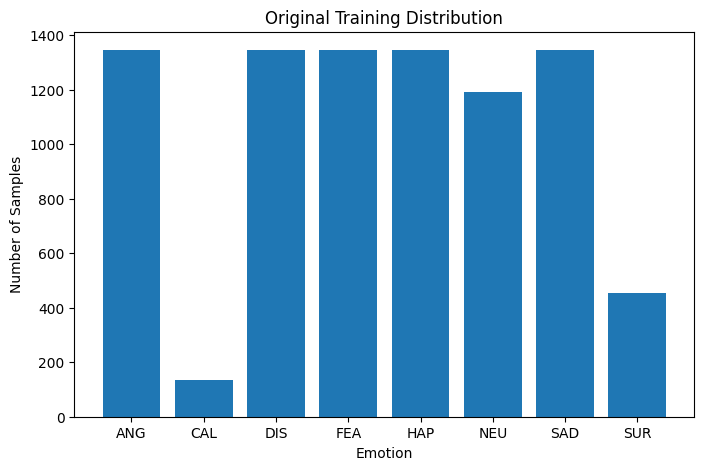

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

original_counts = Counter(train_labels)

labels = [id2emotion[i] for i in sorted(original_counts.keys())]
values = [original_counts[i] for i in sorted(original_counts.keys())]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Original Training Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.show()

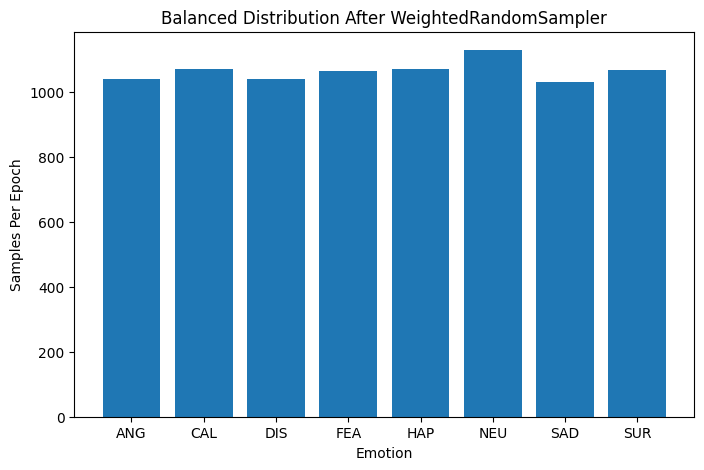

In [ ]:
balanced_counts = Counter(balanced_labels)

labels = [id2emotion[i] for i in sorted(balanced_counts.keys())]
values = [balanced_counts[i] for i in sorted(balanced_counts.keys())]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Balanced Distribution After WeightedRandomSampler")
plt.xlabel("Emotion")
plt.ylabel("Samples Per Epoch")
plt.show()

In [ ]:
from transformers import Wav2Vec2Processor

processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base"
)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

In [ ]:
def collate_fn(batch):

    audios = [x[0] for x in batch]
    labels = torch.tensor([x[1] for x in batch])

    inputs = processor(
        audios,
        sampling_rate=16000,
        padding=True,
        return_tensors="pt"
    )

    return inputs.input_values, labels

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    sampler=sampler,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
from transformers import Wav2Vec2Model

wav2vec = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
).to(device)

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for name, param in wav2vec.named_parameters():

    if "encoder.layers.10" in name or "encoder.layers.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [ ]:
import torch.nn.functional as F

class SERModel(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.bilstm = nn.LSTM(
            input_size=768,
            hidden_size=256,
            batch_first=True,
            bidirectional=True
        )

        self.layer_norm = nn.LayerNorm(512)

        self.attention = nn.Sequential(
            nn.Linear(512,256),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(256,1)
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(512,num_classes)


    def forward(self, x):

        x = F.layer_norm(x, x.shape[-1:])

        lstm_out,_ = self.bilstm(x)

        lstm_out = self.layer_norm(lstm_out)

        attn_weights = torch.softmax(
            self.attention(lstm_out), dim=1
        )

        context = torch.sum(attn_weights * lstm_out, dim=1)

        context = self.dropout(context)

        output = self.fc(context)

        return output

In [ ]:
model = SERModel(num_classes=num_classes).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
optimizer = torch.optim.Adam(

    list(model.parameters()) +
    list(filter(lambda p: p.requires_grad, wav2vec.parameters())),

    lr=1e-4
)

In [ ]:
epochs = 30
best_val_acc = 0

patience = 5
counter = 0
best_epoch = 0

for epoch in range(epochs):

    if epoch == 5:
        for name, param in wav2vec.named_parameters():
            if "encoder.layers.8" in name:
                param.requires_grad = True

    model.train()
    wav2vec.train()

    correct, total = 0, 0
    total_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        features = wav2vec(inputs).last_hidden_state
        outputs = model(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    #  VALIDATION
    model.eval()
    wav2vec.eval()

    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            features = wav2vec(inputs).last_hidden_state
            outputs = model(features)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total


    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Train Loss:", round(train_loss,4))
    print("Train Acc :", round(train_acc,4))
    print("Val Acc   :", round(val_acc,4))

    # SAVE BEST
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        torch.save({
            "wav2vec": wav2vec.state_dict(),
            "model": model.state_dict()
        }, "best_model.pth")

        print("✅ Best model saved")

        counter = 0

    else:
        counter += 1

    # EARLY STOPPING
    if counter >= patience:
        print(f"\nEpoch {epoch+1}: early stopping")
        print(f"Restoring model weights from best epoch: {best_epoch}")
        print("\n⛔ Early Stopping Triggered")
        break


Epoch 1
Train Loss: 1.8865
Train Acc : 0.3542
Val Acc   : 0.206
✅ Best model saved

Epoch 2
Train Loss: 1.3898
Train Acc : 0.4861
Val Acc   : 0.2014

Epoch 3
Train Loss: 1.2031
Train Acc : 0.5575
Val Acc   : 0.1921

Epoch 4
Train Loss: 1.0306
Train Acc : 0.6245
Val Acc   : 0.169

Epoch 5
Train Loss: 0.9054
Train Acc : 0.6682
Val Acc   : 0.2569
✅ Best model saved

Epoch 6
Train Loss: 0.7604
Train Acc : 0.7341
Val Acc   : 0.3495
✅ Best model saved

Epoch 7
Train Loss: 0.6299
Train Acc : 0.7738
Val Acc   : 0.4236
✅ Best model saved

Epoch 8
Train Loss: 0.5748
Train Acc : 0.7961
Val Acc   : 0.5023
✅ Best model saved

Epoch 9
Train Loss: 0.5101
Train Acc : 0.8284
Val Acc   : 0.7569
✅ Best model saved

Epoch 10
Train Loss: 0.4192
Train Acc : 0.8557
Val Acc   : 0.7917
✅ Best model saved

Epoch 11
Train Loss: 0.3446
Train Acc : 0.8839
Val Acc   : 0.8472
✅ Best model saved

Epoch 12
Train Loss: 0.2909
Train Acc : 0.9038
Val Acc   : 0.8426

Epoch 13
Train Loss: 0.2898
Train Acc : 0.9028
Val Acc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import librosa
import numpy as np

def load_audio(path):

    audio, sr = librosa.load(
        path,
        sr=16000
    )

    return audio

In [ ]:
model_path = "/content/drive/MyDrive/best_modelSR (8).pth"

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(model_path, map_location=device)

wav2vec.load_state_dict(checkpoint["wav2vec"])
model.load_state_dict(checkpoint["model"])

wav2vec.eval()
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        features = wav2vec(inputs).last_hidden_state
        outputs = model(features)

        preds = torch.argmax(outputs, dim=1)
        probs = torch.softmax(outputs, dim=1) # Calculate probabilities

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy()) # Store probabilities


accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print("Test Accuracy:", accuracy)
print("Macro F1 Score:", f1)

Test Accuracy: 0.9183561643835616
Macro F1 Score: 0.9254960153770129


In [ ]:
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        features = wav2vec(inputs).last_hidden_state
        outputs = model(features)

        probs = torch.softmax(outputs, dim=1)   # convert logits → probabilities
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy array
all_probs = np.array(all_probs)

In [ ]:
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=emotions
    )
)


Classification Report:

              precision    recall  f1-score   support

         ANG       0.96      0.87      0.91       289
         CAL       1.00      0.86      0.92        28
         DIS       0.88      0.93      0.90       288
         FEA       0.92      0.89      0.91       289
         HAP       0.94      0.94      0.94       289
         NEU       0.92      0.94      0.93       255
         SAD       0.86      0.93      0.89       289
         SUR       1.00      0.99      0.99        98

    accuracy                           0.92      1825
   macro avg       0.94      0.92      0.93      1825
weighted avg       0.92      0.92      0.92      1825



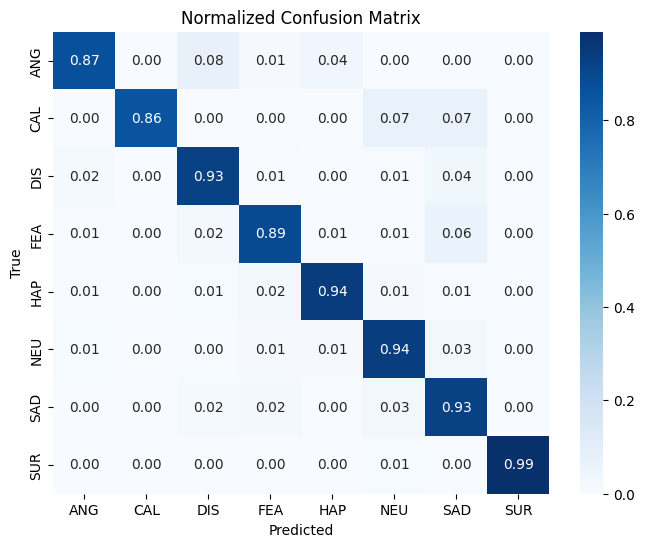

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

# Normalize
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=emotions,
            yticklabels=emotions,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

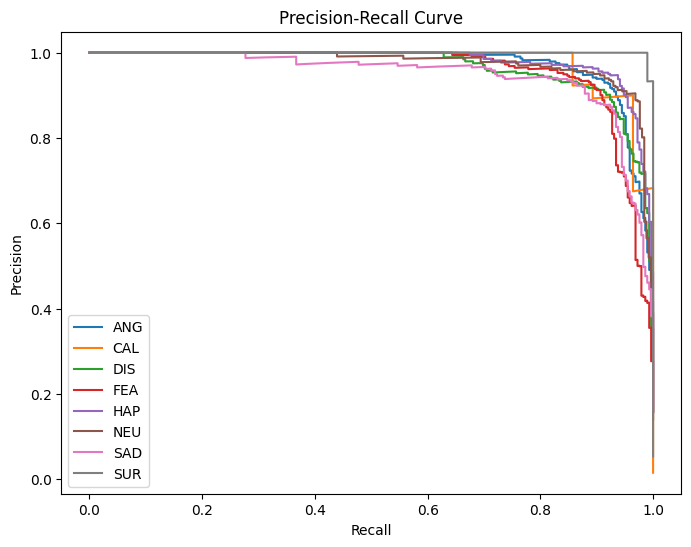

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true[:, i], all_probs[:, i])
    plt.plot(recall, precision, label=emotions[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

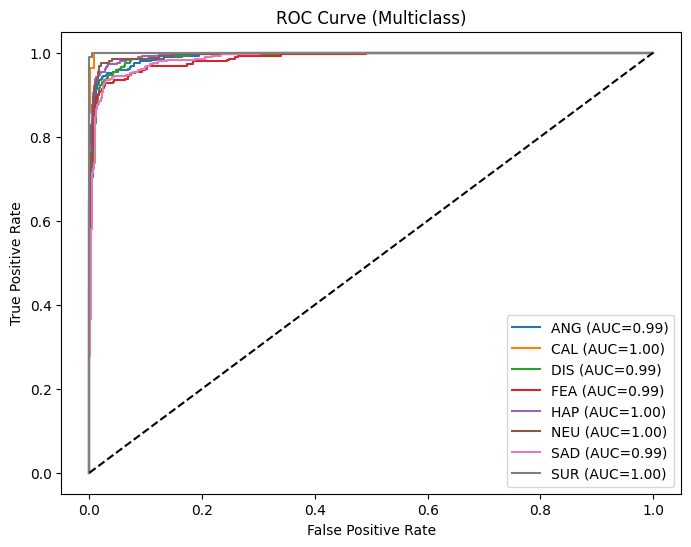

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize labels
y_true = label_binarize(all_labels, classes=list(range(num_classes)))

# Compute ROC for each class
plt.figure(figsize=(8,6))

# Convert all_probs to numpy array for indexing
all_probs_np = np.array(all_probs)

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], all_probs_np[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{emotions[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass)")
plt.legend()
plt.show()

In [ ]:
# =========================
# 🔹 COLLECT PREDICTIONS + PROBABILITIES
# =========================
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, log_loss,
    matthews_corrcoef, cohen_kappa_score
)
import numpy as np
import time

all_preds = []
all_labels = []
all_probs = []

start_time = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        features = wav2vec(inputs).last_hidden_state
        outputs = model(features)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

end_time = time.time()

all_probs = np.array(all_probs)

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print("Accuracy:", accuracy)
print("Macro F1:", f1)

logloss = log_loss(all_labels, all_probs)
print("Log Loss:", logloss)

mcc = matthews_corrcoef(all_labels, all_preds)
print("MCC:", mcc)

kappa = cohen_kappa_score(all_labels, all_preds)
print("Cohen Kappa:", kappa)

cm = confusion_matrix(all_labels, all_preds)


class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nClass-wise Accuracy:")
for i, acc in enumerate(class_acc):
    print(f"{emotions[i]}: {acc:.2f}")

# latency
total_time = end_time - start_time
avg_time = total_time / len(all_labels)

print("\nTotal Inference Time:", total_time)
print("Average per sample:", avg_time)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=emotions))

Accuracy: 0.9194520547945205
Macro F1: 0.9304648528162685
Log Loss: 0.29957460033201594
MCC: 0.9056940754173934
Cohen Kappa: 0.9054526449118174

Class-wise Accuracy:
ANG: 0.87
CAL: 0.93
DIS: 0.93
FEA: 0.89
HAP: 0.94
NEU: 0.94
SAD: 0.93
SUR: 0.98

Total Inference Time: 55.1733341217041
Average per sample: 0.030231963902303618

Classification Report:

              precision    recall  f1-score   support

         ANG       0.96      0.87      0.91       289
         CAL       1.00      0.93      0.96        28
         DIS       0.88      0.93      0.90       288
         FEA       0.92      0.89      0.91       289
         HAP       0.94      0.94      0.94       289
         NEU       0.92      0.94      0.93       255
         SAD       0.87      0.93      0.90       289
         SUR       1.00      0.98      0.99        98

    accuracy                           0.92      1825
   macro avg       0.94      0.93      0.93      1825
weighted avg       0.92      0.92      0.92      182

In [ ]:
import librosa
import numpy as np

def load_audio(path):

    audio, sr = librosa.load(
        path,
        sr=16000
    )

    return audio

TESTING


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import matplotlib.pyplot as plt

from transformers import Wav2Vec2Processor, Wav2Vec2Model
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


emotions = ['ANG', 'CAL', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD', 'SUR']

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)

class SERModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.bilstm = nn.LSTM(768, 256, batch_first=True, bidirectional=True)
        self.layer_norm = nn.LayerNorm(512)
        self.attention = nn.Sequential(
            nn.Linear(512, 256),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.layer_norm(x, x.shape[-1:])
        lstm_out, _ = self.bilstm(x)
        lstm_out = self.layer_norm(lstm_out)

        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)

        context = self.dropout(context)
        return self.fc(context)

model = SERModel(len(emotions)).to(device)


from google.colab import drive
drive.mount('/content/drive')

model_path = "/content/drive/MyDrive/best_modelSR (8).pth"  # change if needed

checkpoint = torch.load(model_path, map_location=device)
wav2vec.load_state_dict(checkpoint["wav2vec"])
model.load_state_dict(checkpoint["model"])

wav2vec.eval()
model.eval()

print("✅ Model Loaded")


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model Loaded


Saving 1001_DFA_HAP_XX.wav to 1001_DFA_HAP_XX.wav
File: 1001_DFA_HAP_XX.wav

 Predicted Emotion: HAP

Probabilities:
ANG : 0.05
CAL : 0.0
DIS : 0.002
FEA : 0.009
HAP : 0.927
NEU : 0.01
SAD : 0.001
SUR : 0.001


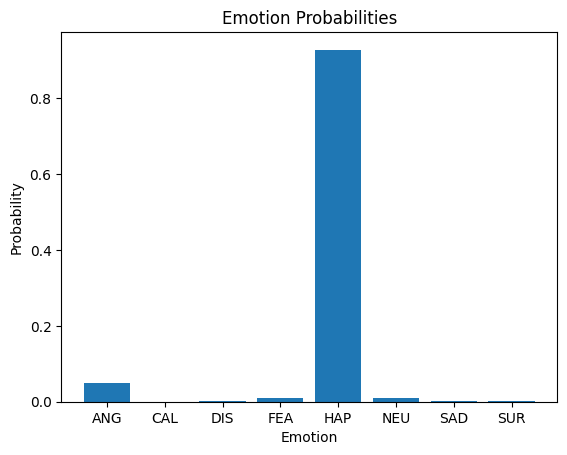


🎧 Recommended Music: energetic  party songs playlist


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
from IPython.display import display, HTML


uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print("File:", file_name)

def predict_emotion(audio_path):
    audio, sr = librosa.load(audio_path, sr=16000)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    ).input_values.to(device)

    with torch.no_grad():
        features = wav2vec(inputs).last_hidden_state
        logits = model(features)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_id = np.argmax(probs)
    predicted_emotion = emotions[pred_id]

    print("\n Predicted Emotion:", predicted_emotion)
    print("\nProbabilities:")
    for i, e in enumerate(emotions):
        print(e, ":", round(probs[i], 3))

    return probs, predicted_emotion

probs, predicted_emotion = predict_emotion(file_name)


plt.figure()
plt.bar(emotions, probs)
plt.title("Emotion Probabilities")
plt.xlabel("Emotion")
plt.ylabel("Probability")
plt.show()


def recommend_music(predicted_emotion):
    emotion_to_prompt = {
         "ANG": "calming relaxing instrumental music",
         "SAD": "uplifting happy songs playlist",
         "FEA": "peaceful soothing  instrumental music",
         "DIS": "light feel good  songs",
         "HAP": "energetic  party songs playlist",
         "CAL": "soft relaxing  lofi music",
         "NEU": "pleasant light songs",
         "SUR": "fun upbeat songs"
    }

    prompt = emotion_to_prompt[predicted_emotion]
    url = f"https://www.youtube.com/results?search_query={prompt.replace(' ','+')}"

    print("\n🎧 Recommended Music:", prompt)
    display(HTML(f'<a href="{url}" target="_blank">👉 Open Music</a>'))

recommend_music(predicted_emotion)

In [2]:
!jupyter nbconvert --ClearMetadataPreprocessor.enabled=True --inplace FINAL_SER.ipynb

[NbConvertApp] WARNING | pattern 'FINAL_SER.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    E